# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

import wandb

In [3]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: anton-bertelsen (pefu-it-university-of-copenhagen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

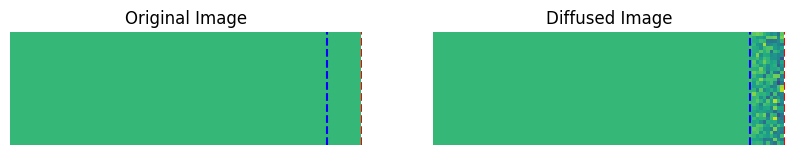

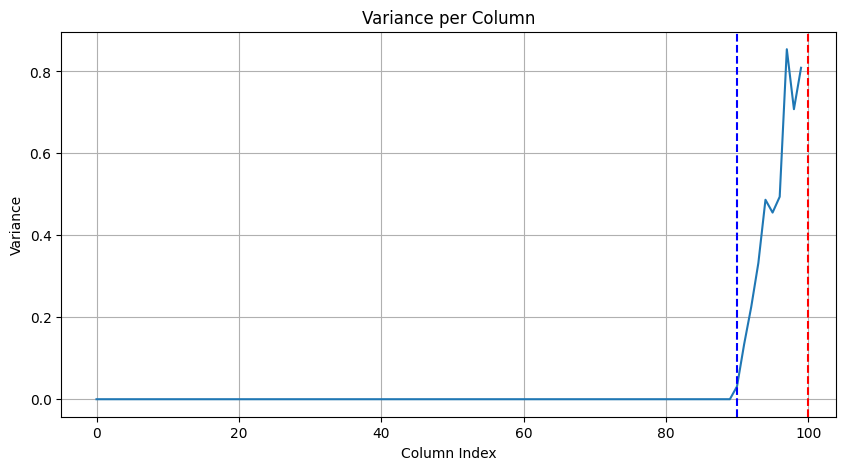

In [5]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 90, 
        num_of_timestep_frames = 10, 
        num_of_post_timestep_frames = 0, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.45),
        device = device 
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((32, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(sequence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [6]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [7]:
model = ContinuousMotionModel(
        diffusion_noise_scheduler=Diffusion(
            device=device,
            num_of_pre_timestep_frames=50,
            num_of_timestep_frames=50,
            num_of_post_timestep_frames=0,
            noise_schedule = Diffusion.linear_schedule(0.00015, 0.15)),
        number_of_styles = 17,
        n_gesture_length = 100,
        audio_features_per_frame = 37,
        pose_features_per_frame = 32,
        number_of_attention_heads = 8,
        debugger = Debugger(
            on=False, 
            keys_for_printing_while_running=["ALL"]
        ),
        device=device,
)

In [8]:
num_of_timestap_stackings = 2
time_step_stacking_indexs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
num_of_timestep_frames = 4

for time_step_stacking_index in time_step_stacking_indexs:
    timesteps_at_frames = [(t + 1) * num_of_timestap_stackings - (time_step_stacking_index % num_of_timestap_stackings) for t in range(num_of_timestep_frames)]
    print(timesteps_at_frames, " with size: ", len(timesteps_at_frames), " must be equal to: ", num_of_timestep_frames)  
    

[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4


In [9]:
# Load the model
# Load and fix the state dictionary
state_dict = torch.load('v1_models/first_tests_started_2025-05-14_13-41-26/first_tests_started_2025-05-14_13-41-26_epoch_84_step_0.pth', map_location=device)
new_state_dict = {}
for key, value in state_dict.items():
    # Remove the _orig_mod. prefix
    new_key = key.replace("_orig_mod.", "")
    new_state_dict[new_key] = value

# Then load the fixed state dict
model.load_state_dict(new_state_dict)
model.to(device)
model.eval()

ContinuousMotionModel(
  (time_step_mlp): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
  )
  (style_linear): Linear(in_features=17, out_features=64, bias=True)
  (audio_linear): Linear(in_features=37, out_features=64, bias=True)
  (noisy_gesture_linear): Linear(in_features=32, out_features=256, bias=True)
  (pre_local_attention_linear): Linear(in_features=384, out_features=256, bias=True)
  (multi_head_local_attention): LocalMHA(
    (to_qkv): Linear(in_features=256, out_features=768, bias=False)
    (attn_fn): LocalAttention(
      (dropout): Dropout(p=0.0, inplace=False)
      (rel_pos): SinusoidalEmbeddings()
    )
    (to_out): Linear(in_features=256, out_features=256, bias=False)
  )
  (relative_positional_embedding_funtion): SinusoidalEmbeddings()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): 

In [10]:
from variational_autoencoder import VAE
# Load the model for inference
vae_model = VAE()
vae_model.to(device)
vae_model.load_state_dict(torch.load("vae_beta_12-05-2025-first-test.pth"))

<All keys matched successfully>

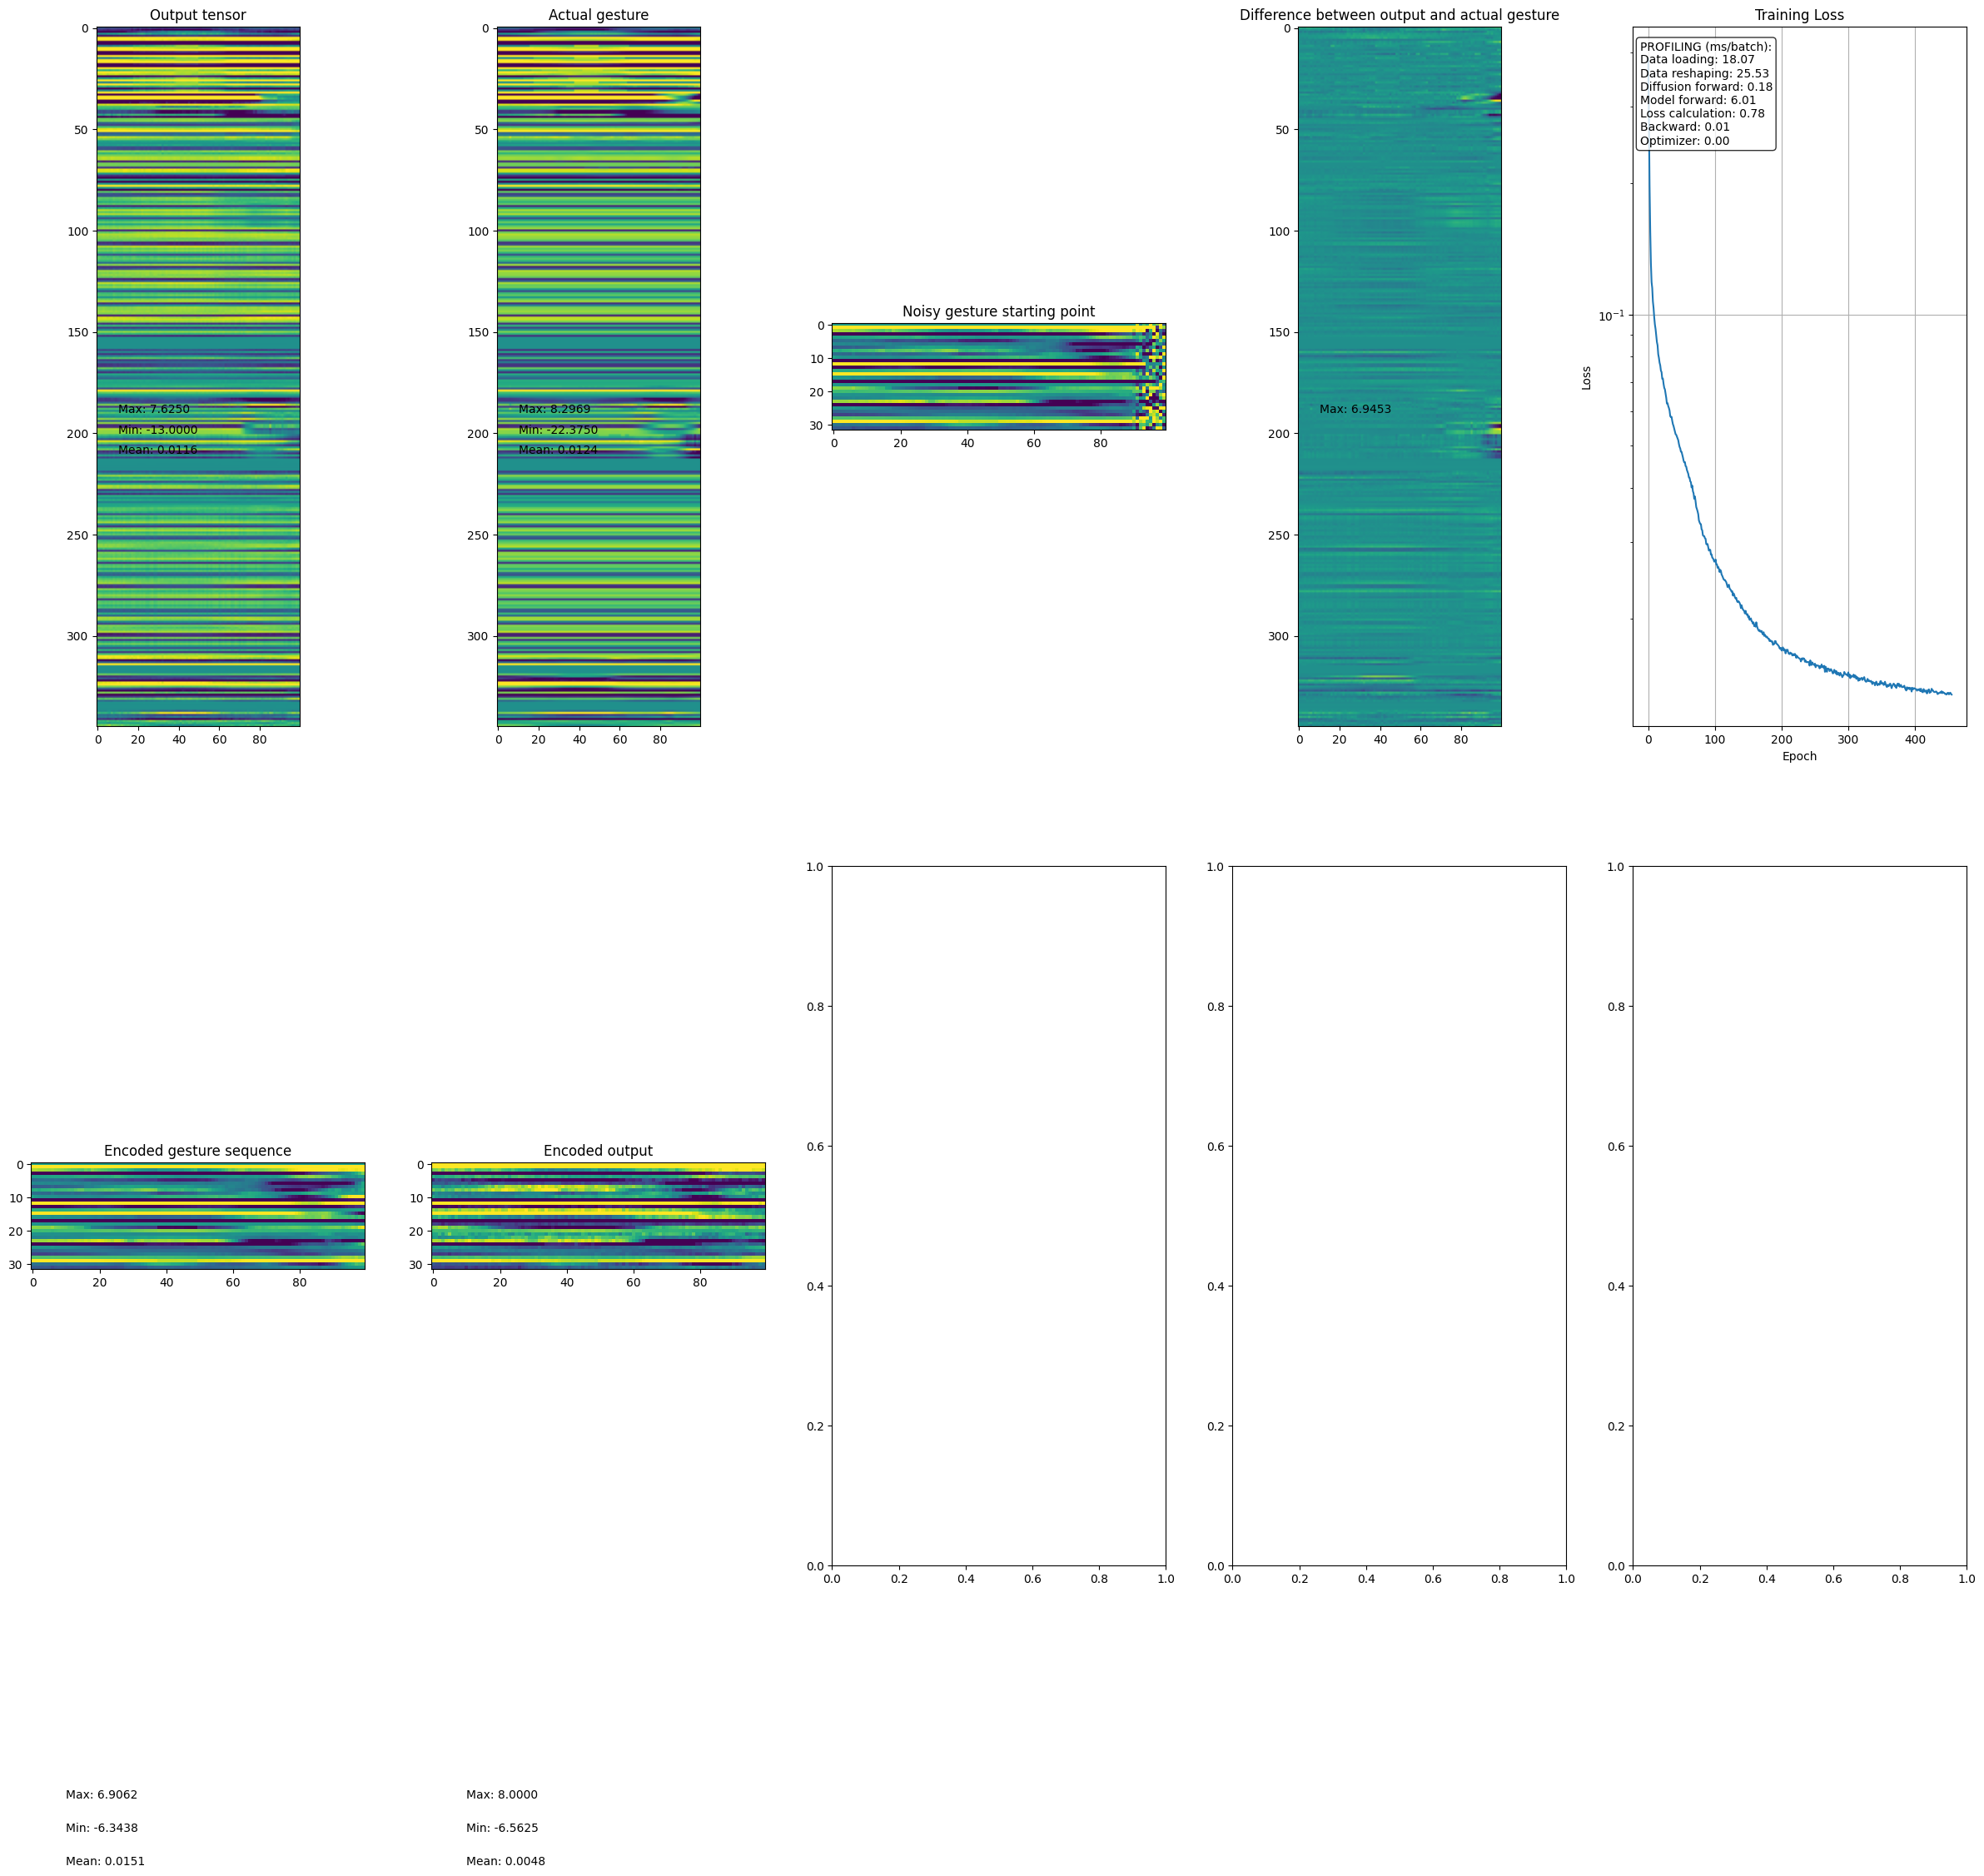

Epoch 5/1000:  55%|█████▌    | 2753/5000 [04:27<05:54,  6.35it/s, loss=0.014] 

Visualisation time: 0.73 s


Epoch 5/1000:  55%|█████▌    | 2761/5000 [04:28<03:41, 10.13it/s, loss=0.0144]

In [ ]:
from torch.utils.data import DataLoader
from dataset.dataset import *

train(
    debug_run=True,
    experiment_collection_name="first_tests",
    model_check_point_interval_in_epochs = 2, # how often to save the model checkpoint - set to infinity to disable
    upload_model_check_point = False, # should upload the model checkpoint to wandb
    model_checkpoint_dir="v1_models",
    model=model,
    autoencoder_model=vae_model,
    device=device,
    training_loader=DataLoader(
            ConsolidatedRAMDataset(
                consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
                seq_length=100,
                seed_length=0,
                batch_size=256,
                epoch_length=5000
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = True
        ),
    val_loader=None, 
    num_epochs=1000,
    lr=0.000005,
    variance_loss_weight = 0.1,
    velocity_loss_weight = 0.1,
    acceleration_loss_weight = 0.1,
    category_weighting = {
        'fingers': 0.1,
        'arms': 2.0,
        'legs': 1.0,
        'spine': 2.0,
        'head': 1.0,
        'root': 2.0
    }
)

In [ ]:
torch.save(model.state_dict(), "new_model_test.pth")

In [21]:
from dataset.dataset import *
from utils.bvh_processing.bvh_converter import BVHParser
# Load an example from the dataset
dataset = ConsolidatedRAMDataset(
    consolidated_file="dataset/genea2023_dataset/trn/main-agent/consolidated.npz",
    seq_length=100,
    seed_length=0,
    batch_size=1,
    epoch_length=1,  # Set to 1 for testing purposes
    return_audio_frame_index=True,  # Set to True to return the audio frame index
)

iter_dataset = iter(dataset)


Found 2002399 valid starting points for windows


In [43]:
import animation_visualisation
animation_visualisation.init_visualization()

Visualization already running.
HTTP Server: http://localhost:8000
WebSocket Server: ws://localhost:8700
Viewer URL: http://localhost:8000/bvh_tests/bvh_visualisation/bvh_viewer_5.html?wsport=8700


8700

In [44]:
from IPython.display import clear_output
from torch.amp import autocast
import time
import soundfile as sf

draw = False


dataset = ConsolidatedRAMDataset(
    consolidated_file="dataset/genea2023_dataset/toy_test/main-agent/consolidated.npz",
    seq_length=100,
    seed_length=0,
    batch_size=1,
    epoch_length=1,  # Set to 1 for testing purposes
    return_audio_frame_index=True,  # Set to True to return the audio frame index
)


# Now I want to test the autoregressive generation of the model
# model = torch.compile(model, backend="cudagraphs")

# Use no gradient calculation for inference
with torch.no_grad():
    # Get a sample from the dataset
    # gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame, file = next(iter(dataset))
    gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, start_frames = next(iter(dataset))
    gesture_sequence = gesture_sequence.to(device)
    seed_gesture = seed_gesture.to(device)
    audio_features = audio_features.to(device)
    main_agent_id_one_hot = main_agent_id_one_hot.to(device)
    full_audio_features = dataset.audio.to(device)
    start_frame = start_frames[0].item()  # Extract the first element from the tensor

    # gesture_sequence = gesture_sequence * 0.1  # Scale the gesture sequence to a smaller range

    with autocast(device_type=device.type, dtype=torch.bfloat16):
        # Decode the output using the autoencoder model
        gesture_sequence_encoded, _ = vae_model.encode(gesture_sequence)
        # print(f"Output shape after decoding: {output.shape}")
        # print(f"Original output shape: {encoded_output.shape}")

    diffusion = model.diffusion_noise_scheduler

    # Apply noise to the gesture_sequence using the diffusion process
    noisy_gesture_sequence = diffusion.forward(
        sequence_tensor=gesture_sequence_encoded,
        stacking_step=0,
    )
    # noisy_gesture_sequence = gesture_sequence

    # Load std_pose and mean_pose from statistics.npz
    statistics = np.load("dataset/genea2023_dataset/trn/main-agent/statistics.npz")
    mean_pose = torch.tensor(statistics['mean_pose']).to(device)
    std_pose = torch.tensor(statistics['std_pose']).to(device)

    target_joints = ['body_world', 'b_root', 'b_r_foot', 'b_l_foot', 'b_l_upleg', 'b_l_leg', 'b_r_upleg', 'b_r_leg', 
                    'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3', 'b_l_shoulder', 'b_l_arm', 'b_l_arm_twist', 
                    'b_l_forearm', 'b_l_wrist_twist', 'b_l_wrist', 'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3', 'b_l_ring1', 
                    'b_l_ring2', 'b_l_ring3', 'b_l_middle1', 'b_l_middle2', 'b_l_middle3', 'b_l_index1', 'b_l_index2', 
                    'b_l_index3', 'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3', 'b_r_shoulder', 'b_r_arm', 
                    'b_r_arm_twist', 'b_r_forearm', 'b_r_wrist_twist', 'b_r_wrist', 'b_r_thumb0', 'b_r_thumb1', 
                    'b_r_thumb2', 'b_r_thumb3', 'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3', 'b_r_middle1', 'b_r_middle2', 
                    'b_r_middle3', 'b_r_ring1', 'b_r_ring2', 'b_r_ring3', 'b_r_index1', 'b_r_index2', 'b_r_index3', 
                    'b_neck0', 'b_head']

    bvh_template = "bvh_tests/bvh/template.bvh"

    # Load the BVH file and extract features
    parser = BVHParser(bvh_template, target_joints)
    # features = parser.extract_channels()


    # In order to send audio I will find the equivalent wav file for the current gesture sequence
    # wav_file = os.path.join(os.path.dirname(os.path.dirname(file)), 'wav', os.path.basename(file).replace('.npz', '_main-agent.wav'))
    # if not os.path.exists(wav_file):
    #     raise ValueError(f"Corresponding wav file {wav_file} not found.")
    
    # print("Wav file: ", wav_file)

    # Read the wav file
    # audio_data, samplerate = sf.read(wav_file)

    start_time = time.time()
    iteration_counter = 0
    while True:
        frame_start_time = time.time()
        debug_time_start = time.time()

        # Shift the gesture_sequence by one frame
        shifted_gesture_sequence = torch.roll(noisy_gesture_sequence, shifts=-1, dims=1)

        # print the duration of the shift operation in miliseconds
        debug_time_end = time.time()
        print(f"Time taken for shift operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")
        

        # Replace the last frame with pure noise
        shifted_gesture_sequence[0,-1] = torch.zeros_like(shifted_gesture_sequence[0,-1])

        # print the duration of the noise operation
        debug_time_start = time.time()
        print(f"Time taken for noise operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        # Apply diffusion noise to the shifted_gesture_sequence
        shifted_gesture_sequence = diffusion.forward(sequence_tensor=shifted_gesture_sequence, stacking_step=0)

        # print the duration of the diffusion operation
        debug_time_end = time.time()
        print(f"Time taken for diffusion operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")

        # The audio features also have to be shifted by one frame
        # I have the full audio features and the starting frame, so I extract the audio features for the current frame
        print("audio_features.shape: ", audio_features.shape)
        actual_audio_features = full_audio_features[start_frame + iteration_counter: start_frame + iteration_counter + shifted_gesture_sequence.shape[1], :].unsqueeze(0)

        # print the duration of the audio feature extraction operation
        debug_time_start = time.time()
        print(f"Time taken for audio feature extraction operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        with autocast(device_type=device.type, dtype=torch.bfloat16):
            # Convert all inputs to same precision as autocast context

            # denoised_gesture_sequence = shifted_gesture_sequence
            denoised_gesture_sequence = model(
                current_time_step_stacking_level = 0,
                one_hot_style = main_agent_id_one_hot,
                audio_features = actual_audio_features, 
                noisy_gesture_sequence = shifted_gesture_sequence,
                condition_mask_probabilty = 0.0,
            )
            # denoised_gesture_sequence = shifted_gesture_sequence

            # print the duration of the model operation
            debug_time_end = time.time()
            print(f"Time taken for model operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")

            # The above is essentially hole filling, so we replace the first 90 frames with the original shifted_gesture_sequence
            denoised_gesture_sequence[0, :50] = shifted_gesture_sequence[0, :50]

            # print the duration of the replacement operation
            debug_time_start = time.time()
            print(f"Time taken for replacement operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")
        
        # Clear old output
        clear_output(wait=True)

        # # Visualize the audio features and denoised gesture sequence stacked vertically
        if draw:
            fig, axs = plt.subplots(2, 1, figsize=(5, 10))
            
            # Audio features on top subplot
            im1 = axs[0].imshow(actual_audio_features.squeeze(0).permute(1, 0).cpu().detach().numpy(), 
                                cmap='viridis', aspect='auto', vmin=-1, vmax=1)
            axs[0].set_title("Audio Features")
            axs[0].set_ylabel("Feature Index")
            fig.colorbar(im1, ax=axs[0], label='Intensity')
            
            # Denoised gesture sequence on bottom subplot
            im2 = axs[1].imshow(shifted_gesture_sequence.squeeze(0).permute(1, 0).to(torch.float32).cpu().detach().numpy(), 
                                cmap='viridis', aspect='auto', vmin=-1, vmax=1)
            axs[1].set_title("Denoised Gesture Sequence")
            axs[1].set_xlabel("Frame Index")
            axs[1].set_ylabel("Feature Index")
            
            # Draw a vertical line at frame 50
            line_x = 50
            axs[1].axvline(x=line_x, color='red', linestyle='--', label='Pre-timestep frames')
            axs[1].set_xlim(0, shifted_gesture_sequence.shape[1])  # Set x-axis limits to match the image width
            axs[1].legend()
            
            fig.colorbar(im2, ax=axs[1], label='Intensity')
            plt.tight_layout()
            plt.show()

        # print the duration of the visualization operation
        debug_time_end = time.time()
        print(f"Time taken for visualization operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")


        with autocast(device_type=device.type, dtype=torch.bfloat16):
            # Decode the output using the autoencoder model
            denoised_gesture_sequence_unencoded = vae_model.decode(denoised_gesture_sequence)
            # print(f"Output shape after decoding: {output.shape}")
            # print(f"Original output shape: {encoded_output.shape}")

        # Undo the z-score normalization
        unnormalized_gesture_sequence = denoised_gesture_sequence_unencoded * std_pose + mean_pose

        # print the duration of the unnormalization operation
        debug_time_start = time.time()
        print(f"Time taken for unnormalization operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        # extract wav audio for the current frame
        # TODO: Fix offset here, this is awkward. Probably the features_to_websocket_format should not take an index and just handle the frame? Not sure yet.
        # print("samplerate: ", (start_frame + iteration_counter + 49 + 1) * samplerate)

        # per_frame_sample_rate = int(samplerate / 30)

        # print(audio_data.shape, (start_frame + iteration_counter + 49) * per_frame_sample_rate, (start_frame + iteration_counter + 49 + 1) * per_frame_sample_rate)
        # wav_audio = audio_data[(start_frame + iteration_counter + 49) * per_frame_sample_rate : (start_frame + iteration_counter + 49 + 1) * per_frame_sample_rate]
        # frame = parser.features_to_websocket_format(unnormalized_gesture_sequence,wav_audio,samplerate,49)
        frame = parser.features_to_websocket_format(unnormalized_gesture_sequence,frame_idx=49)
        # print ("frame audio: ", frame["audio_chunk"])
        animation_visualisation.send_frame(frame)

        # print the duration of the send frame operation
        debug_time_end = time.time()

        # Update the noisy_gesture_sequence for the next iteration
        noisy_gesture_sequence = denoised_gesture_sequence

        # Calculate the time taken for this iteration
        end_time = time.time()
        iteration_counter += 1
        elapsed_time = end_time - start_time

        # print(f"Time taken for iterations so far: {elapsed_time:.2f} seconds")
        # print(f"Iteration: {iteration_counter}")
        # print(f"iterations per second: {iteration_counter / elapsed_time:.2f}")
        
        frame_end_time = time.time()

        # print elapsed time
        print(f"Elapsed time: {frame_end_time - frame_start_time:.2f} seconds")

        # Sleep for the remaining time in the 30 FPS frame
        time_to_sleep = max(0, (1/30) - (frame_end_time - frame_start_time) - 0.001)  # 0.01 is a small buffer to account for processing time
        time.sleep(time_to_sleep)


Time taken for visualization operation: 1.00 milliseconds
Time taken for unnormalization operation: 0.00 milliseconds
Elapsed time: 0.02 seconds


KeyboardInterrupt: 

In [ ]:
# I will try to run the entire animation just from a single inferrence


# Use no gradient calculation for inference
with torch.no_grad():
    # Load an example from the dataset
    # dataset = SingleSampleAnimationDataset(
    #         folder = "dataset/genea2023_dataset/trn/main-agent/features",
    #         seq_length_in_frames = 150,
    #         seed_length_in_frames = 8,
    #         epoch_length = 5000,
    #        batch_size = 1
    # )

    dataset = ConsolidatedRAMDataset(
            consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
            seq_length=100,
            seed_length=0,
            batch_size=1,
            epoch_length=5000
    )

    # Get a sample from the dataset
    # gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame = [
    gesture_batch, seed_batch, audio_batch, speaker_batch = [
        item.to(device) for item in next(iter(dataset))
    ]
    gesture_sequence = gesture_sequence * 0.1  # Scale the gesture sequence to a smaller range

    diffusion = model.deffsion_noise_scheduler

    # Apply noise to the gesture_sequence using the diffusion process
    noisy_gesture_sequence = diffusion.forward(
        seqence_tensor=gesture_sequence,
        stacking_step=0,
    )

    # Load std_pose and mean_pose from statistics.npz
    statistics = np.load("dataset/genea2023_dataset/trn/main-agent/statistics.npz")
    mean_pose = torch.tensor(statistics['mean_pose']).to(device)
    std_pose = torch.tensor(statistics['std_pose']).to(device)

    target_joints = ['body_world', 'b_root', 'b_r_foot', 'b_l_foot', 'b_l_upleg', 'b_l_leg', 'b_r_upleg', 'b_r_leg', 
                    'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3', 'b_l_shoulder', 'b_l_arm', 'b_l_arm_twist', 
                    'b_l_forearm', 'b_l_wrist_twist', 'b_l_wrist', 'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3', 'b_l_ring1', 
                    'b_l_ring2', 'b_l_ring3', 'b_l_middle1', 'b_l_middle2', 'b_l_middle3', 'b_l_index1', 'b_l_index2', 
                    'b_l_index3', 'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3', 'b_r_shoulder', 'b_r_arm', 
                    'b_r_arm_twist', 'b_r_forearm', 'b_r_wrist_twist', 'b_r_wrist', 'b_r_thumb0', 'b_r_thumb1', 
                    'b_r_thumb2', 'b_r_thumb3', 'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3', 'b_r_middle1', 'b_r_middle2', 
                    'b_r_middle3', 'b_r_ring1', 'b_r_ring2', 'b_r_ring3', 'b_r_index1', 'b_r_index2', 'b_r_index3', 
                    'b_neck0', 'b_head']

    bvh_template = "bvh_tests/bvh/template.bvh"

    # Load the BVH file and extract features
    parser = BVHParser(bvh_template, target_joints)
    # features = parser.extract_channels()

Found 48539 valid starting points for windows


ValueError: not enough values to unpack (expected 6, got 4)

In [ ]:
model.debugger.get_available_keys()
model.debugger.print_from_key("ALL")
